In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns

In [2]:
data_dir = "./pbmc10k/"

adata = sc.read_10x_mtx(
    data_dir,
    var_names='gene_symbols',  # or 'ensembl_ids' if you prefer
    make_unique=True            # ensure gene names are unique
)
adata

AnnData object with n_obs × n_vars = 11769 × 33538
    var: 'gene_ids', 'feature_types'

In [3]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
adata

AnnData object with n_obs × n_vars = 11769 × 33538
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb'

In [4]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

In [5]:
adata = adata[adata.obs['pct_counts_mt'] < 15, :].copy()

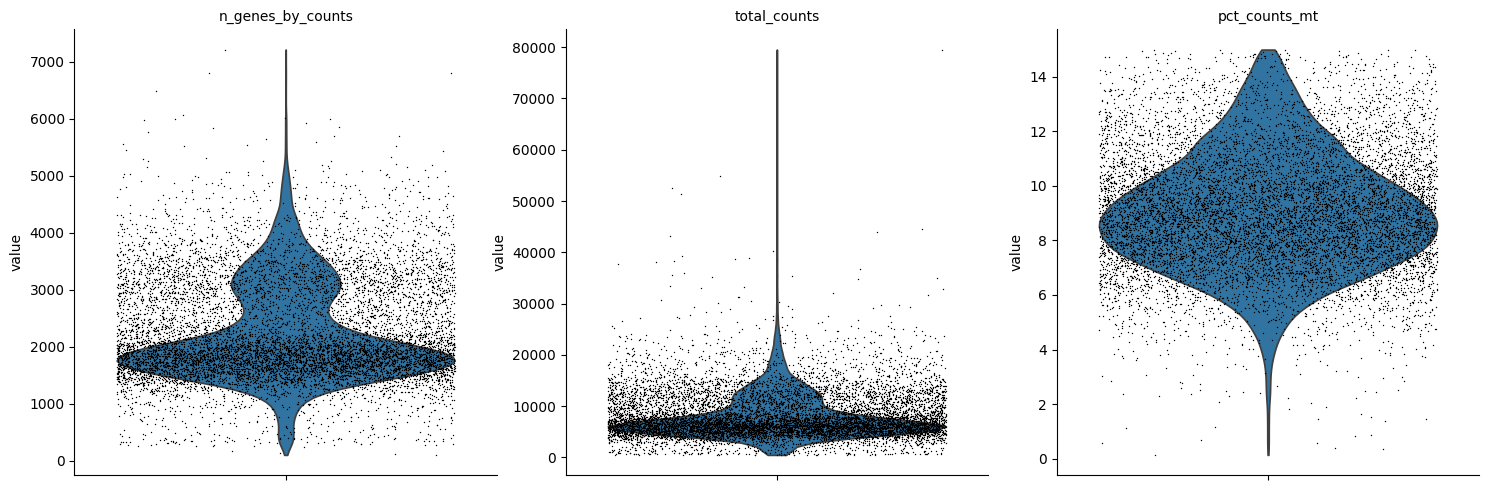

In [7]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    save="pbmc10k_qc.png"
)

In [6]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [7]:
adata.layers["counts"] = adata.X.copy()

In [8]:
# Normalizing to median total counts
sc.pp.normalize_total(adata, target_sum=10**4)
# Logarithmize the data
sc.pp.log1p(adata)

In [48]:
adata.X = adata.X.toarray()

In [49]:
import celltypist
from celltypist import models

In [50]:
model_high = models.Model.load(model="Immune_All_High.pkl")
model_high

CellTypist model with 32 cell types and 6639 features
    date: 2022-07-16 08:53:00.959521
    details: immune populations combined from 20 tissues of 18 studies
    source: https://doi.org/10.1126/science.abl5197
    version: v2
    cell types: B cells, B-cell lineage, ..., pDC precursor
    features: A1BG, A2M, ..., ZYX

In [51]:
predictions_high = celltypist.annotate(
    adata, model=model_high, majority_voting=True
)

🔬 Input data has 10695 cells and 20192 genes
🔗 Matching reference genes in the model
🧬 5474 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


In [52]:
predictions_high_adata = predictions_high.to_adata()
adata.obs["celltypist_cell_label_coarse"] = predictions_high_adata.obs.loc[
    adata.obs.index, "majority_voting"
]
adata.obs["celltypist_conf_score_coarse"] = predictions_high_adata.obs.loc[
    adata.obs.index, "conf_score"
]
adata.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,...,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_genes,predicted_labels,over_clustering,majority_voting,conf_score,celltypist_cell_label_coarse,celltypist_conf_score_coarse
AAACCCAAGCGCCCAT-1,1087,6.992096,2204.0,7.698483,34.437387,44.782214,55.716878,73.366606,52.0,3.970292,...,0.0,0.000000,0.000000,1087,T cells,0,T cells,0.999448,T cells,0.999448
AAACCCAAGGTTCCGC-1,4200,8.343078,20090.0,9.908028,30.751618,43.753111,55.739174,67.819811,1324.0,7.189168,...,2.0,1.098612,0.009955,4200,DC,3,DC,0.990112,DC,0.990112
AAACCCACAGAGTTGG-1,1836,7.515889,5884.0,8.680162,42.641061,52.923182,62.542488,75.254929,633.0,6.452049,...,0.0,0.000000,0.000000,1836,Monocytes,5,Monocytes,0.999988,Monocytes,0.999988
AAACCCACAGGTATGG-1,2216,7.703910,5530.0,8.618124,32.839060,41.681736,51.175407,65.280289,434.0,6.075346,...,1.0,0.693147,0.018083,2216,ILC,8,ILC,1.000000,ILC,1.000000
AAACCCACATAGTCAC-1,1615,7.387709,5106.0,8.538367,41.676459,56.423815,65.648257,78.162946,553.0,6.317165,...,0.0,0.000000,0.000000,1615,B cells,9,B cells,1.000000,B cells,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTCTGTAAC-1,1833,7.514255,5887.0,8.680672,40.631901,53.881434,64.039409,76.065908,632.0,6.450470,...,0.0,0.000000,0.000000,1833,T cells,43,T cells,0.997668,T cells,0.997668
TTTGTTGGTGCGTCGT-1,1336,7.198184,5115.0,8.540128,51.163245,67.565982,74.975562,83.655914,365.0,5.902633,...,0.0,0.000000,0.000000,1336,T cells,86,T cells,0.999420,T cells,0.999420
TTTGTTGGTTTGAACC-1,1401,7.245655,4245.0,8.353733,43.910483,58.186101,67.255595,78.775029,375.0,5.929589,...,0.0,0.000000,0.000000,1401,T cells,43,T cells,0.999156,T cells,0.999156
TTTGTTGTCCAAGCCG-1,1668,7.419980,5602.0,8.631058,45.430203,59.371653,67.832917,79.150303,524.0,6.263398,...,0.0,0.000000,0.000000,1668,T cells,1,T cells,0.999974,T cells,0.999974


In [11]:
import scanpy as sc
import pandas as pd
import os

# Set output directory
output_dir = "pbmc10k1_Result"
os.makedirs(output_dir, exist_ok=True)

# Parameters
hvg_list = [1000]
leiden_resolutions = [0.02, 0.5, 2.0]

for n_hvg in hvg_list:
    print(f"\n--- Processing {n_hvg} HVGs ---")
    
    # Work on a copy to avoid overwriting adata
    adata_hvg = adata.copy()
    
    # Step 1: Select highly variable genes
    sc.pp.highly_variable_genes(adata_hvg, n_top_genes=n_hvg)
    hvg_genes = adata_hvg.var[adata_hvg.var['highly_variable']].index.to_list()
    pd.Series(hvg_genes).to_csv(f"{output_dir}/HVG{n_hvg}_genes.csv", index=False, header=['gene'])
    adata_hvg = adata_hvg[:, adata_hvg.var['highly_variable']].copy()

    # Step 2: PCA
    sc.tl.pca(adata_hvg, svd_solver='arpack')

    # Step 3: Compute neighbors
    sc.pp.neighbors(adata_hvg)
    sc.tl.umap(adata_hvg)
    
    for res in leiden_resolutions:
        print(f" → Running Leiden (resolution={res})")

        adata_hvg1 = adata_hvg.copy()

        # Step 4: Cluster
        sc.tl.leiden(adata_hvg1, resolution=res, key_added=f'leiden_{res}', flavor="igraph")
        
        # Step 5: Export annotated data
        leiden_key = f'leiden_{res}'
        out_prefix = f"HVG{n_hvg}_leiden{res}"
        
        # Save annotated data
        adata_hvg1.obs.to_csv(f"{output_dir}/{out_prefix}_clusters.csv")
        sc.pl.umap(
            adata_hvg1,
            color=[leiden_key, 'celltypist_cell_label_coarse'],
            legend_loc="on data",
            show=False,
            save=f"pbmc10k1_{n_hvg}_{leiden_key}_umap.png"
        )
        # Step 6: Find top 20 marker genes for each cluster
        sc.tl.rank_genes_groups(adata_hvg1, groupby=leiden_key, method='wilcoxon')
        markers = adata_hvg1.uns['rank_genes_groups']
        groups = markers['names'].dtype.names
        top20_list = []
        for g in groups:
            df = pd.DataFrame({g: markers['names'][g][:20]})
            top20_list.append(df)
        top20 = pd.concat(top20_list, axis=1)
        top20.to_csv(f"{output_dir}/{out_prefix}_top20_genes.csv", index=False)
        
        print(f"   ✓ Saved clusters and top20 genes for {out_prefix}")


--- Processing 1000 HVGs ---


/data1/miniconda3/envs/research/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-08 18:23:25.377443: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 18:23:25.427393: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-08 18:23:27.029332: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see

 → Running Leiden (resolution=0.02)
   ✓ Saved clusters and top20 genes for HVG1000_leiden0.02
 → Running Leiden (resolution=0.5)
   ✓ Saved clusters and top20 genes for HVG1000_leiden0.5
 → Running Leiden (resolution=2.0)
   ✓ Saved clusters and top20 genes for HVG1000_leiden2.0


/data1/miniconda3/envs/research/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:456: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/data1/miniconda3/envs/research/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/data1/miniconda3/envs/research/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:461: PerformanceWarni